# BENCHMARKER

This ipynb is made for visualizing "RECALL@K" and "Trade-Offs" of the core search engine built in folder 'core-engine'

## Pre-requisties 

- Creating Samples(50K Size)
- Cleaning The Data
- Running Linear Search for baseline

In [3]:
import sys
import os

# Get the absolute path of the parent directory (the 'searchis' root)
parent_dir = os.path.abspath('..')

# Add the parent directory to Python's module search path
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [4]:
from core_engine.main import run_sanitization_stage,run_vector_stage_faiss
from sentence_transformers import SentenceTransformer
import json
import numpy as np
import torch
import random

/home/rahul/searchis/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Sampling a Small Dataset(50K) documents

Same dataset "ArXiv" just smaller

input.json = "./core-engine/archive/arxiv-metadata-oai-snapshot.json"

output.json = "./dataset/raw-data.json"

Ran Linux command "head -n 50000 input.json > output.json" to sample first 50K documents


### Sanitizing the Raw-Data for further use


In [5]:
raw_data_path = "/home/rahul/searchis/benchmarks/dataset/raw-data.json"
sanitized_path="/home/rahul/searchis/benchmarks/dataset/sanitized-data.json"

In [ ]:
%%time
run_sanitization_stage(raw_data_path,sanitized_path)

Starting data sanitization...
  ...sanitized 50000 documents.
Success! Processed and cleaned 50000 papers.
CPU times: user 1.79 s, sys: 36.9 ms, total: 1.82 s
Wall time: 1.83 s


### Creating Doc_ids List

In [40]:
doc_ids = []
with open(sanitized_path,"r") as f:
    for line in f:
        try:
            record = json.loads(line)
        except json.JSONDecodeError:
            continue #Skip broken lines
        doc_ids.append(record.get("id"))

### Running a Linear Search Algorithm (Ground Truth)

The results of this search algo will work as source of truth or baseline for every other implementation

In [42]:
def generate_ground_truth(sanitized_path: str, output_path: str, num_queries: int = 500, top_k: int = 10):
    """
    Generates a ground truth dataset by running a brute-force exact linear scan.
    
    Encodes all documents fresh from the sanitized data using the same SentenceTransformer
    model, then computes exact cosine similarity via matrix multiplication.
    """
    import gc
    
    # Load the same model used by the FAISS indexer for consistency
    model_name = "all-MiniLM-L6-v2"
    print(f"Loading SentenceTransformer model: {model_name}...")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = SentenceTransformer(model_name, device=device)
    
    # Read all documents and encode them to get exact (non-quantized) embeddings
    print(f"Reading documents from {sanitized_path}...")
    doc_ids = []
    texts = []
    with open(sanitized_path, "r") as f:
        for line in f:
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                continue
            doc_ids.append(record.get("id"))
            full_text = record.get("clean_title", "") + ". " + record.get("clean_abstract", "")
            texts.append(full_text.strip())
    
    total_docs = len(doc_ids)
    print(f"Read {total_docs} documents. Encoding embeddings...")
    
    # Encode all documents with normalized embeddings (same as FAISS indexer)
    embeddings = model.encode(
        texts,
        show_progress_bar=True,
        normalize_embeddings=True,
        batch_size=256,
    )
    
    # Free text data from memory
    del texts
    gc.collect()
    
    # Move to PyTorch tensors for fast matrix multiplication
    pt_device = torch.device(device)
    embeddings = torch.from_numpy(embeddings).to(pt_device)
    
    if num_queries > total_docs:
        num_queries = total_docs
        
    print(f"Randomly selecting {num_queries} synthetic queries...")
    # Pick random document indices to act as our test queries
    query_indices = random.sample(range(total_docs), num_queries)
    
    query_embeddings = embeddings[query_indices]
    query_ids = [doc_ids[i] for i in query_indices]
    
    # Embeddings are already L2-normalized from encode(), so dot product = cosine similarity
    print("Computing exact brute-force cosine similarity (The O(N) linear scan)...")
    # [num_queries, 384] @ [384, total_docs] -> [num_queries, total_docs] matrix of scores.
    similarity_matrix = torch.matmul(query_embeddings, embeddings.T)
    
    # We fetch top_k + 1 because the #1 closest document to the query will always be the query itself!
    print(f"Extracting the absolute Top {top_k} nearest neighbors...")
    top_scores, top_indices = torch.topk(similarity_matrix, k=top_k + 1, dim=1)
    
    ground_truth = {}
    
    # Move indices back to CPU for normal Python processing
    top_indices = top_indices.cpu().numpy()
    
    for i, query_id in enumerate(query_ids):
        neighbors = []
        # Iterate over the top K+1 indices
        for idx in top_indices[i]:
            neighbor_id = doc_ids[idx]
            
            # Skip the query document itself (we don't want it in the search results)
            if neighbor_id == query_id:
                continue
                
            neighbors.append(str(neighbor_id)) 
            
            # Stop once we have exactly top_k true neighbors
            if len(neighbors) == top_k:
                break
                
        # Store in our dictionary
        ground_truth[str(query_id)] = neighbors
        
    print(f"Saving ground truth to {output_path}...")
    with open(output_path, 'w') as f:
        json.dump(ground_truth, f, indent=4)
        
    print("Ground truth generation complete! You can now use this to test your LSH/FAISS recall.")


#### Ran this on Google Colab T4 GPU 
 `generate_ground_path(sanitized_path,vectored_path_faiss)`

## Custom Lexical Search Engine


### Tokenizing The data

In [7]:
from core_engine.main import run_tokenization_stage
tokenized_path = "./dataset/tokenized-data.json"

In [11]:
%%time
run_tokenization_stage(sanitized_path,tokenized_path)

Starting Tokenization...
  ...tokenized 50000 documents.
Success! Output File Path:-./dataset/tokenized-data.json 
CPU times: user 6.71 s, sys: 50.7 ms, total: 6.77 s
Wall time: 6.8 s


### Indexing The Tokenized Data

In [8]:
from core_engine.main import run_indexation_stage
inverted_indexed_path = "./dataset/inverted-indices.json"

In [13]:
%%time
run_indexation_stage(tokenized_path,inverted_indexed_path)

Starting Indexing.....
  ...indexed 50000 documents.
  Packing remaining in-memory postings...
  Writing to ./dataset/inverted-indices.json.tmp (~0.0 GB)...
  ✓ Index saved: 50,000 docs, 131,074 terms, 2,617,478 postings, 20.3 MB on disk.
Successfully Indexed:50000 documents
CPU times: user 4.5 s, sys: 170 ms, total: 4.67 s
Wall time: 4.69 s


### Lexical-Search

Search was done from file `multiprocessor.py` it was specially optimize to work with all avaible CPU cores
,since Jupyter Notebooks cannot do that

In [12]:
with open("./dataset/final_recall_lexical.json","r") as f:
    recall_list = json.load(f)
recall_list = [(recall,k1,round(b,1)) for recall,k1,b in recall_list]
print(recall_list[:10])

[(0.4, 0.5, 0.2), (0.7, 0.5, 0.2), (0.3, 0.5, 0.2), (0.4, 0.5, 0.2), (0.0, 0.5, 0.2), (0.9, 0.5, 0.2), (0.5, 0.5, 0.2), (0.2, 0.5, 0.2), (0.6, 0.5, 0.2), (0.4, 0.5, 0.2)]


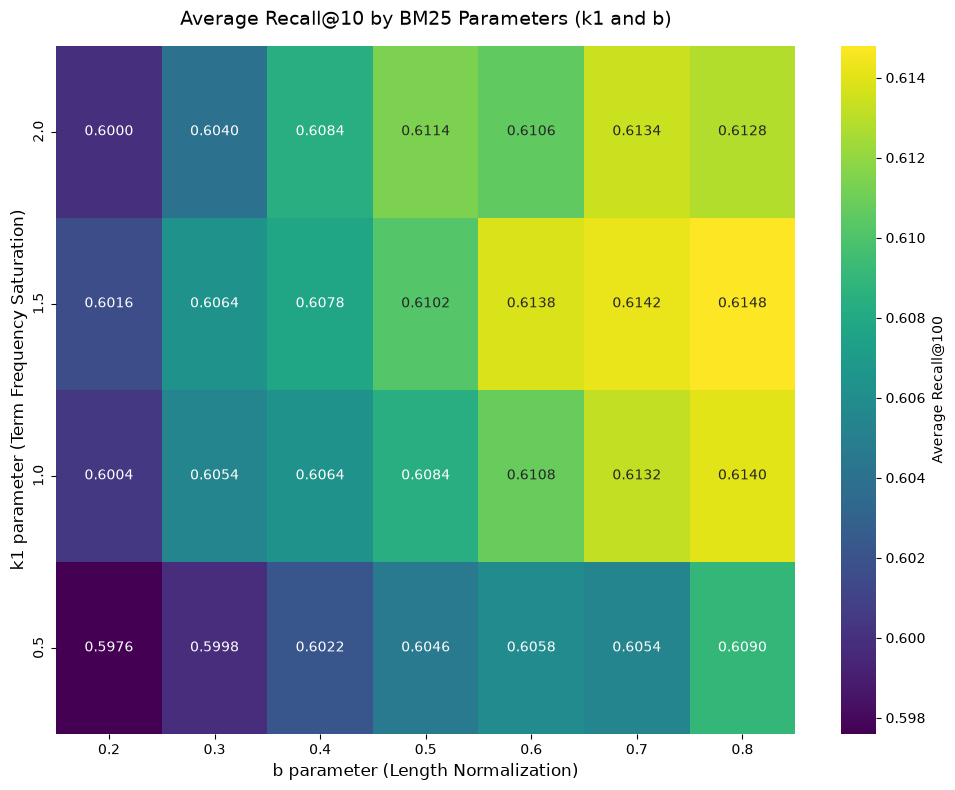

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame(recall_list, columns=['Recall', 'k1', 'b'])


avg_recall_df = df.groupby(['k1', 'b'])['Recall'].mean().reset_index()


# Rows = k1, Columns = b, Values = Average Recall
heatmap_data = avg_recall_df.pivot(index='k1', columns='b', values='Recall')

plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_data, 
    annot=True, 
    cmap='viridis', 
    fmt=".4f", # Formats the numbers to 4 decimal places
    cbar_kws={'label': 'Average Recall@100'}
)

plt.title('Average Recall@10 by BM25 Parameters (k1 and b)', fontsize=14, pad=15)
plt.xlabel('b parameter (Length Normalization)', fontsize=12)
plt.ylabel('k1 parameter (Term Frequency Saturation)', fontsize=12)

# Invert Y-axis so the lowest k1 value starts at the bottom (optional but standard)
plt.gca().invert_yaxis()

# 7. Render the plot
plt.tight_layout()
plt.show()

## Custom LSH Searcher Algo

### Sampling Data

Since entire function is written in Python its painfully slow so we will only sample 10K documents and 100 queries

In [37]:
raw_data_path_10k = "/home/rahul/searchis/benchmarks/dataset-10k/raw-data-10k.json"
sanitized_path_10k = "/home/rahul/searchis/benchmarks/dataset-10k/sanitized-10k.json"
ground_truth_10k = "/home/rahul/searchis/benchmarks/dataset-10k/ground-truth-10k.json"

In [38]:
run_sanitization_stage(raw_data_path_10k,sanitized_path_10k)

Starting data sanitization...
Success! Processed and cleaned 10000 papers.


In [ ]:
from core_engine.vectored_index import CustomVectorIndex
from core_engine.main import run_vector_stage_custom


100

In [43]:
generate_ground_truth(sanitized_path_10k,ground_truth_10k,100,10)

Loading SentenceTransformer model: all-MiniLM-L6-v2...
Reading documents from /home/rahul/searchis/benchmarks/dataset-10k/sanitized-10k.json...
Read 10000 documents. Encoding embeddings...


Batches: 100%|██████████| 40/40 [06:38<00:00,  9.95s/it]


Randomly selecting 100 synthetic queries...
Computing exact brute-force cosine similarity (The O(N) linear scan)...
Extracting the absolute Top 10 nearest neighbors...
Saving ground truth to /home/rahul/searchis/benchmarks/dataset-10k/ground-truth-10k.json...
Ground truth generation complete! You can now use this to test your LSH/FAISS recall.


### Load sanitized docs and ground truth

In [51]:
import gc
texts = []
doc_ids_10k = []
with open(sanitized_path_10k) as f:
    for line in f:
        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            continue
        doc_ids_10k.append(rec["id"])
        texts.append(
            (rec.get("clean_title", "") + ". " + rec.get("clean_abstract", "")).strip()
        )

with open(ground_truth_10k) as f:
    gt = json.load(f)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
print(f"🧠  Encoding {len(texts)} docs on {device} …")
embeddings = model.encode(texts, show_progress_bar=True,
                           normalize_embeddings=True, batch_size=256)
del texts
gc.collect()

🧠  Encoding 10000 docs on cpu …


Batches: 100%|██████████| 40/40 [04:58<00:00,  7.45s/it]


### Run Grid Search

In [53]:
from core_engine.lsh_custom_class import LSH
import  core_engine.hasher as hasher
num_bits_list=(64, 128, 256)
b_list=(4, 8, 16, 32)
top_k=10
"""
    For every valid (num_bits, b) pair, build the LSH index, query it
    for each ground-truth query, and record:
        • recall@k
        • number of candidate indices returned
    """
query_ids = list(gt.keys())
# Build a lookup: doc_id → integer index
id2idx = {did: i for i, did in enumerate(doc_ids_10k)}
query_indices = [id2idx[qid] for qid in query_ids]

num_dims = embeddings.shape[1]     # 384 for all-MiniLM-L6-v2
results = []   # list of dicts

combos = [(nb, b) for nb in num_bits_list for b in b_list if nb % b == 0]
print(f"\n🔍  Running grid search over {len(combos)} configurations …")

for num_bits, b in combos:
    r = num_bits // b
    label = f"bits={num_bits}, b={b}, r={r}"
    print(f"  ⚙  {label}")

    # ---- generate random hyperplanes ----
    np.random.seed(42)   # reproducible across configs
    hyperplanes = np.random.randn(num_bits, num_dims)

    # ---- hash all docs ----
    lsh = LSH(b=b)
    for emb in embeddings:
        sig = hasher.get_signature(hyperplanes, emb)
        lsh.add_hash(sig)

    # ---- query each GT entry ----
    recalls, cand_counts = [], []
    for qid, q_idx in zip(query_ids, query_indices):
        q_emb = embeddings[q_idx]
        q_sig = hasher.get_signature(hyperplanes, q_emb)

        cand_indices = lsh.get_candidates(q_sig)
        if isinstance(cand_indices, set):
            cand_indices = list(cand_indices)

        num_candidates = len(cand_indices)
        cand_counts.append(num_candidates)

        # ---- re-rank candidates by exact cosine → recall@k ----
        if num_candidates == 0:
            recalls.append(0.0)
            continue

        scores = []
        for cidx in cand_indices:
            if cidx == q_idx:
                continue  # skip self
            cos = np.dot(q_emb, embeddings[cidx]) / (
                np.linalg.norm(q_emb) * np.linalg.norm(embeddings[cidx]) + 1e-10
            )
            scores.append((doc_ids[cidx], float(cos)))

        scores.sort(key=lambda x: x[1], reverse=True)
        retrieved = {s[0] for s in scores[:top_k]}
        relevant = set(gt[qid])
        recall = len(retrieved & relevant) / max(len(relevant), 1)
        recalls.append(recall)

    avg_recall = np.mean(recalls)
    avg_cands  = np.mean(cand_counts)
    pct_scanned = avg_cands / len(doc_ids_10k) * 100

    results.append({
        "num_bits": num_bits, "b": b, "r": r,
        "avg_recall": avg_recall,
        "avg_candidates": avg_cands,
        "pct_dataset": pct_scanned,
        "all_cand_counts": cand_counts,
    })
    print(f"       recall@{top_k}={avg_recall:.3f}  |  "
            f"avg candidates={avg_cands:.0f} ({pct_scanned:.1f}% of N)")



🔍  Running grid search over 12 configurations …
  ⚙  bits=64, b=4, r=16
       recall@10=0.025  |  avg candidates=8 (0.1% of N)
  ⚙  bits=64, b=8, r=8
       recall@10=0.410  |  avg candidates=677 (6.8% of N)
  ⚙  bits=64, b=16, r=4
       recall@10=0.983  |  avg candidates=7373 (73.7% of N)
  ⚙  bits=64, b=32, r=2
       recall@10=1.000  |  avg candidates=9999 (100.0% of N)
  ⚙  bits=128, b=4, r=32
       recall@10=0.000  |  avg candidates=1 (0.0% of N)
  ⚙  bits=128, b=8, r=16
       recall@10=0.042  |  avg candidates=12 (0.1% of N)
  ⚙  bits=128, b=16, r=8
       recall@10=0.623  |  avg candidates=1241 (12.4% of N)
  ⚙  bits=128, b=32, r=4
       recall@10=0.998  |  avg candidates=9232 (92.3% of N)
  ⚙  bits=256, b=4, r=64
       recall@10=0.000  |  avg candidates=1 (0.0% of N)
  ⚙  bits=256, b=8, r=32
       recall@10=0.000  |  avg candidates=1 (0.0% of N)
  ⚙  bits=256, b=16, r=16
       recall@10=0.069  |  avg candidates=20 (0.2% of N)
  ⚙  bits=256, b=32, r=8
       recall@10=0

### Visualizations

In [54]:
def pareto_frontier(xs, ys):
    """Return indices of points on the Pareto frontier (max y, min x)."""
    pts = sorted(zip(xs, ys, range(len(xs))), key=lambda t: (t[0], -t[1]))
    best_y, front = -1, []
    for x, y, i in pts:
        if y > best_y:
            best_y = y
            front.append(i)
    return front

#### Scatter: Y=Recall@10, X=Avg Candidates. Pareto frontier drawn.

✅  Saved → dataset-10k/lsh_recall_vs_candidates.png


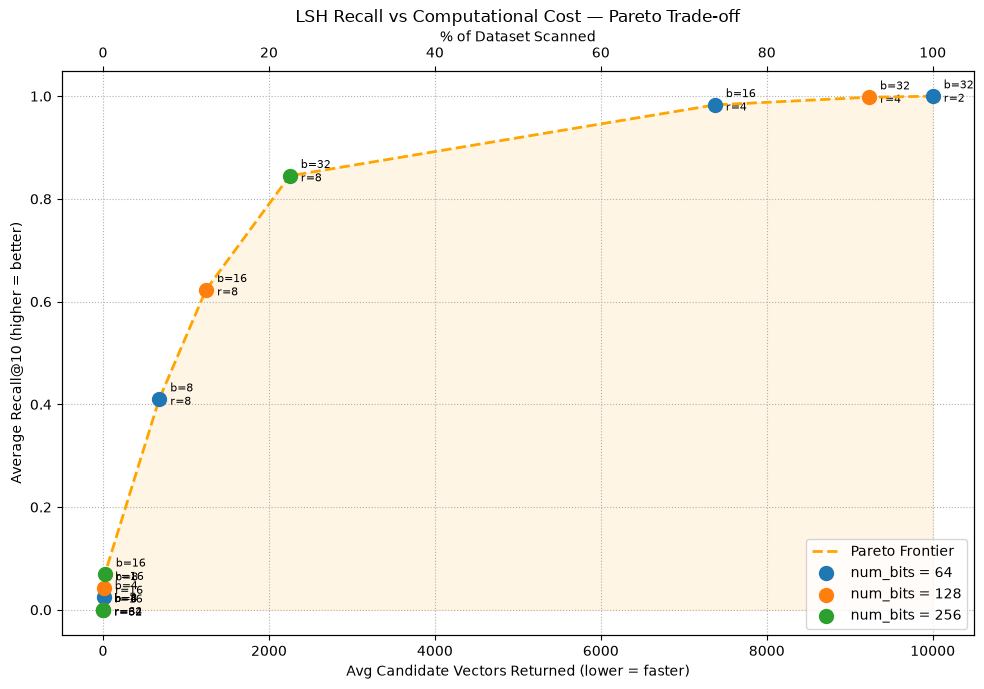

In [58]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))

# Extract all xs and ys for the Pareto frontier calculation
xs = [r["avg_candidates"] for r in results]
ys = [r["avg_recall"] for r in results]

# 1. Plot Pareto Frontier first (standard orange)
front = pareto_frontier(xs, ys)
fx = [xs[i] for i in front] + [xs[front[-1]]]
fy = [ys[i] for i in front] + [ys[front[-1]]]
ax.plot(fx, fy, "--", color="orange", linewidth=2, label="Pareto Frontier", zorder=4)
ax.fill_between(fx, fy, alpha=0.1, color="orange")

# 2. Scatter Points (grouped by num_bits to use matplotlib's default color cycle)
bits_vals = sorted(set(r["num_bits"] for r in results))
for bv in bits_vals:
    # Filter data for this specific bit value
    b_xs = [r["avg_candidates"] for r in results if r["num_bits"] == bv]
    b_ys = [r["avg_recall"] for r in results if r["num_bits"] == bv]
    
    # Matplotlib automatically assigns a new color for each scatter call
    ax.scatter(b_xs, b_ys, s=100, label=f"num_bits = {bv}", zorder=5)

# 3. Annotations
for r in results:
    ax.annotate(f"b={r['b']}\nr={r['r']}",
                (r["avg_candidates"], r["avg_recall"]),
                textcoords="offset points", xytext=(8, -4), fontsize=8)

# 4. Formatting & Legend
ax.legend(loc="lower right")  # Automatically grabs the scatter and pareto labels!
ax.set_xlabel("Avg Candidate Vectors Returned (lower = faster)")
ax.set_ylabel("Average Recall@10 (higher = better)")
ax.set_title("LSH Recall vs Computational Cost — Pareto Trade-off")
ax.grid(True, linestyle=":")

# 5. Secondary X-axis
ax2 = ax.twiny()
n_docs = 10_000
ax2.set_xlim(ax.get_xlim()[0]/n_docs*100, ax.get_xlim()[1]/n_docs*100)
ax2.set_xlabel("% of Dataset Scanned")

fig.tight_layout()
path = "dataset-10k/lsh_recall_vs_candidates.png"
fig.savefig(path)
print(f"✅  Saved → {path}")

#### Grouped histograms of candidate counts across b values (fixed num_bits=128)

✅  Saved → dataset-10k/lsh_bucket_load_histogram.png


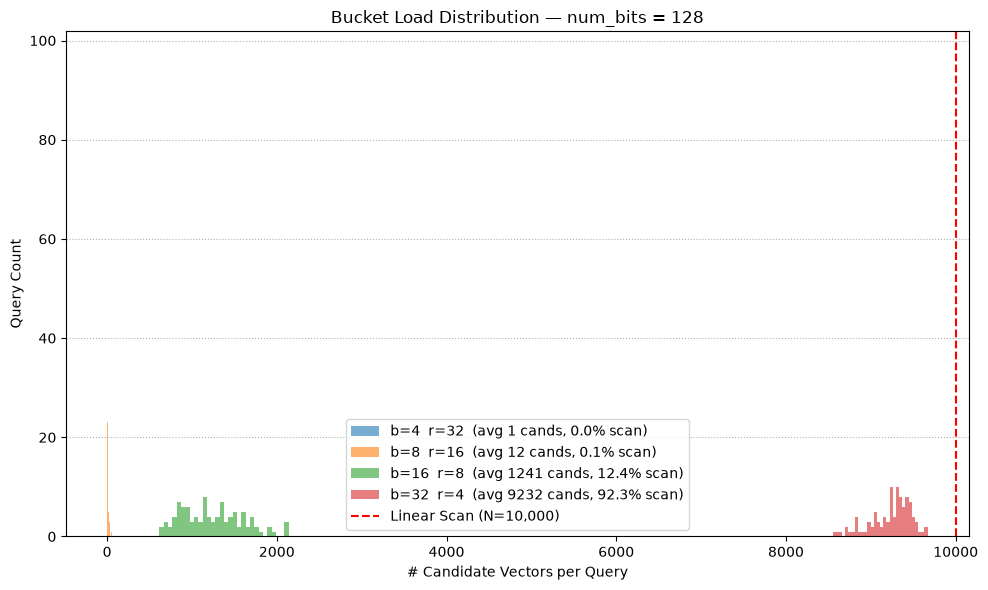

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Filter for target bits (fallback if not found)
target_bits = 128
subset = [r for r in results if r["num_bits"] == target_bits]
if not subset:
    target_bits = results[0]["num_bits"]
    subset = [r for r in results if r["num_bits"] == target_bits]

fig, ax = plt.subplots(figsize=(10, 6))

# 1. Plot Histograms (Matplotlib auto-cycles colors per loop iteration)
for r in sorted(subset, key=lambda x: x["b"]):
    b, rv = r["b"], r["r"]
    cc = r["all_cand_counts"]
    pct = r["pct_dataset"]
    
    ax.hist(cc, bins=30, alpha=0.6, 
            label=f"b={b}  r={rv}  (avg {np.mean(cc):.0f} cands, {pct:.1f}% scan)")

# 2. Baseline Line
ax.axvline(x=10_000, color="red", linestyle="--", label="Linear Scan (N=10,000)")

# 3. Formatting & Legend
ax.set_xlabel("# Candidate Vectors per Query")
ax.set_ylabel("Query Count")
ax.set_title(f"Bucket Load Distribution — num_bits = {target_bits}")
ax.legend()
ax.grid(True, axis="y", linestyle=":")

fig.tight_layout()
path = "dataset-10k/lsh_bucket_load_histogram.png"
fig.savefig(path)
print(f"✅  Saved → {path}")

#### Theoretical LSH S-curve: P(collision) = 1 - (1 - s^r)^b

✅  Saved → dataset-10k/lsh_s_curve.png


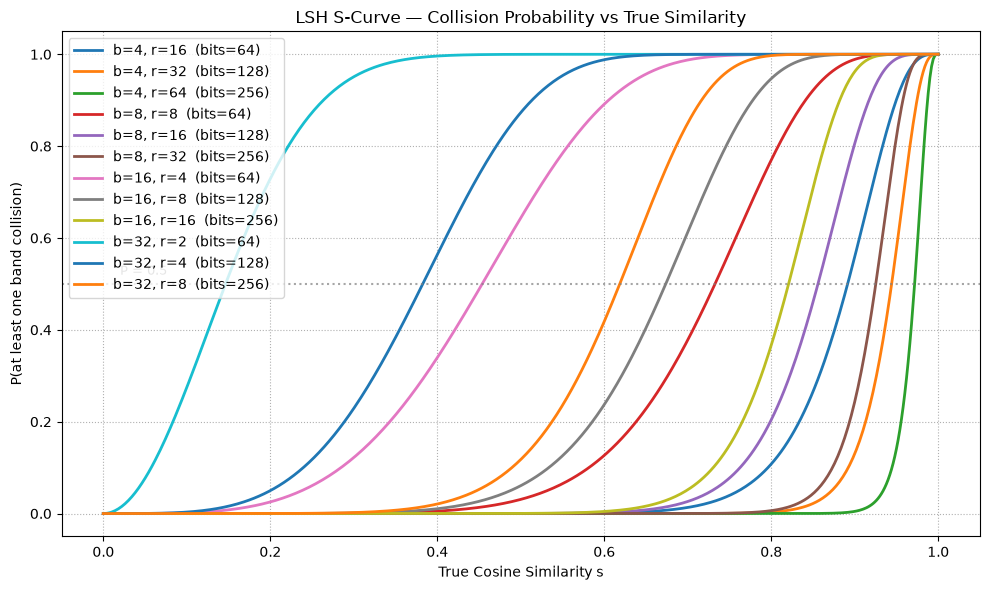

In [60]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
s_range = np.linspace(0, 1, 500)

# 1. Plot S-Curves (Matplotlib assigns a new color for each line automatically)
combos = sorted(set((r["b"], r["r"]) for r in results))
for b, r in combos:
    P = 1 - (1 - s_range**r)**b
    ax.plot(s_range, P, linewidth=2, label=f"b={b}, r={r}  (bits={b*r})")

# 2. Threshold Line
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.7)
ax.text(0.02, 0.52, "P = 0.5", color="gray", fontsize=9)

# 3. Formatting & Legend
ax.set_xlabel("True Cosine Similarity s")
ax.set_ylabel("P(at least one band collision)")
ax.set_title("LSH S-Curve — Collision Probability vs True Similarity")
ax.legend(loc="upper left")  # Stripped the dark-mode box styling
ax.grid(True, linestyle=":")

fig.tight_layout()
path = "dataset-10k/lsh_s_curve.png"
fig.savefig(path)
print(f"✅  Saved → {path}")

#### Heatmap: rows=num_bits, cols=b, values=avg recall@10

✅  Saved → dataset-10k/lsh_recall_heatmap.png


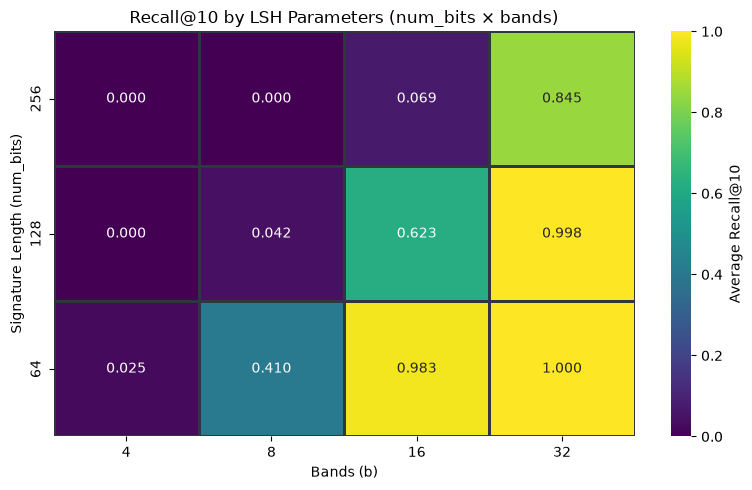

In [62]:

import pandas as pd
rows = [{"num_bits": r["num_bits"], "b": r["b"],
            "Recall@10": r["avg_recall"]} for r in results]
df = pd.DataFrame(rows)
pivot = df.pivot(index="num_bits", columns="b", values="Recall@10")

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", linewidths=1,
            linecolor="#30363d", ax=ax,
            cbar_kws={"label": "Average Recall@10"})
ax.set_title("Recall@10 by LSH Parameters (num_bits × bands)")
ax.set_xlabel("Bands (b)")
ax.set_ylabel("Signature Length (num_bits)")
ax.invert_yaxis()

fig.tight_layout()
path = "dataset-10k/lsh_recall_heatmap.png"
fig.savefig(path)
print(f"✅  Saved → {path}")

